# 01 — EDA: WM-811K Wafer Defect Detection

Goal: understand class distribution, wafer-map dimensions, and per-defect visual patterns before building the preprocessing stage.

**Note the imbalance.** Most wafers are `none`. Document this — it drives the preprocessing strategy.

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


## Load dataset

Download `LSWMD.pkl` from Kaggle and place it in `../data/`.

In [2]:
import os

import pandas as pd

CLEAN = "../data/LSWMD_clean.pkl"
RAW = '../data/LSWMD.pkl'

if os.path.exists(CLEAN):
    df = pd.read_pickle(CLEAN)
else:
    import sys
    import pandas.core.indexes as _idx
    import pandas.core.indexes.base as _base

    sys.modules['pandas.indexes'] = _idx
    sys.modules['pandas.indexes.base'] = _base

    import pickle

    with open(RAW, 'rb') as f:
        df = pickle.load(f, encoding='latin1')

    sys.modules.pop('pandas.indexes', None)
    sys.modules.pop('pandas.indexes.base', None)
    df = df.reset_index(drop=True)
    df.to_pickle(CLEAN)
    print('Saved clean pickle:', CLEAN)

In [3]:

df = pd.read_pickle('../data/LSWMD_clean.pkl')
print(df.shape)
df.head()

(811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [4]:
import numpy as np

# failureType is stored as nested arrays — normalize to a clean string column
df['failureType'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, np.ndarray) and x.size > 0 else 'unlabeled'
)
df['failureType'].value_counts()

failureType
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

## Class distribution

Separate labeled vs. unlabeled. The ~172k labeled subset is what you train on.

Labeled wafers: 172950


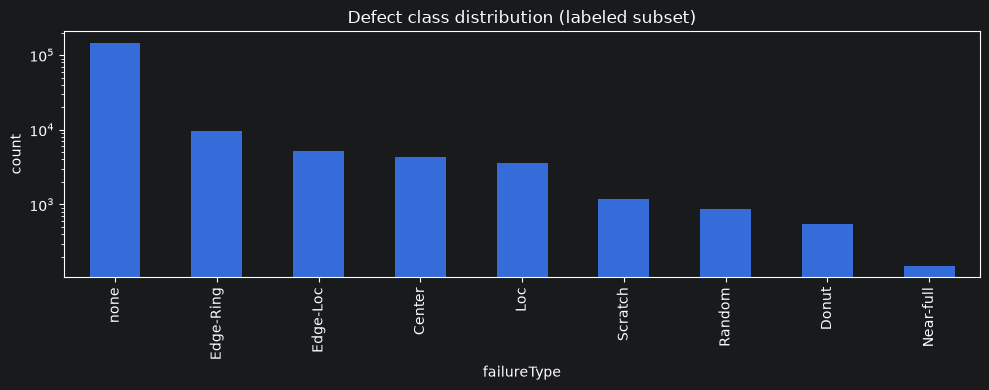

In [5]:
import matplotlib.pyplot as plt

labeled = df[df['failureType'] != 'unlabeled'].copy()
print('Labeled wafers:', len(labeled))

plt.figure(figsize=(10, 4))
labeled['failureType'].value_counts().plot(kind='bar')
plt.title('Defect class distribution (labeled subset)')
plt.ylabel('count')
plt.yscale('log')
plt.tight_layout()
plt.show()

## Wafer-map dimensions

Maps vary in size — confirm the range so the preprocessing resize target is justified.

In [6]:
labeled['dim'] = labeled['waferMap'].apply(lambda m: m.shape)
print(labeled['dim'].value_counts().head(10))

dim
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64


## Visualize one example per defect type

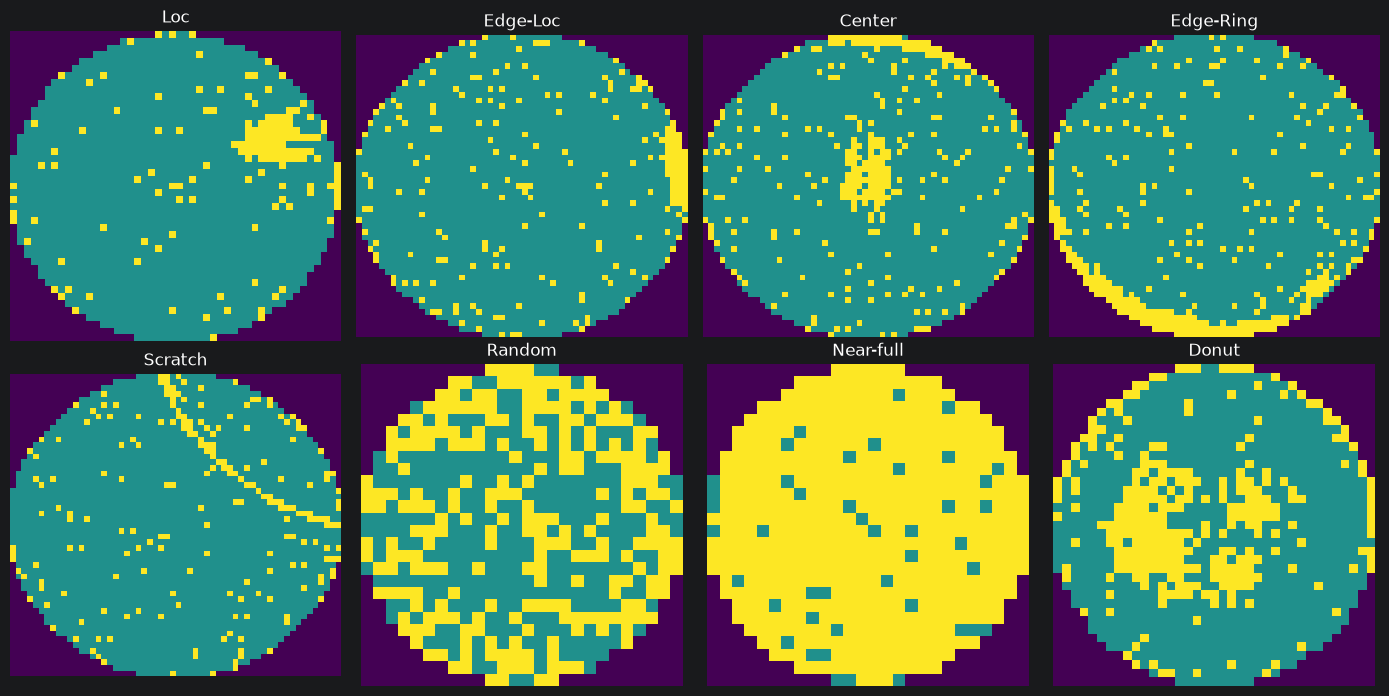

In [7]:
types = [t for t in labeled['failureType'].unique() if t != 'none']
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, t in zip(axes.ravel(), types):
    sample = labeled[labeled['failureType'] == t]['waferMap'].iloc[0]
    ax.imshow(sample)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Notes / decisions

- **Resize target:** 64×64 — preserves spatial defect patterns (including thin Scratch/Loc features) while staying light on 6GB VRAM. 32×32 risks losing fine patterns; 128×128 is heavier with marginal gain.

- **Imbalance strategy:** Drop the `none` class (~85% of labeled data) and classify the 8 true defect patterns. Apply oversampling / augmentation for minority classes (Near-full, Donut, which have <few hundred samples).

- **Classes to keep / merge:** Keep all 8 defect classes (Center, Donut, Edge-Loc, Edge-Ring, Loc, Random, Scratch, Near-full). No merging — each is physically distinct.

- **Next stage (02_preprocessing):** filter to 8 classes → resize to 64×64 → handle imbalance → stratified train/val/test split.